# Testing RouteLearner class

---

In [2]:
import numpy as np
from main import RouteLearner, greedy_solver
import random
from matplotlib import pyplot as plt
np.random.seed(9582735)
random.seed(43875634)

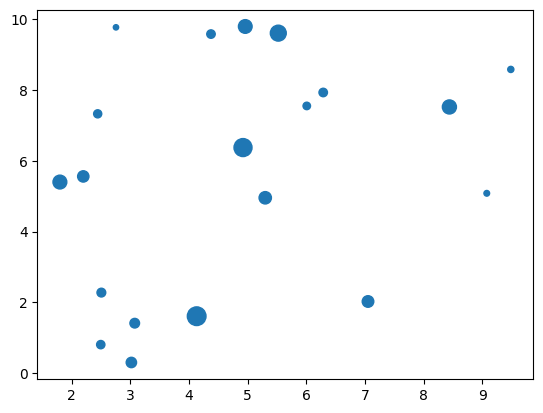

In [3]:
num_nodes = 20
dim = 2
points = np.random.rand(num_nodes, dim)*10
true_lambdas = np.random.lognormal(mean=2, sigma=1, size=num_nodes)
time_window = 40
rl = RouteLearner(points, true_lambdas, time_window)

plt.scatter(rl.points[:, 0], rl.points[:, 1], s=true_lambdas*5)
plt.show()

[ 7.9825134   7.42252068  7.15358641 33.58602091 11.14515257 20.54434977
 15.79441029 19.80997581  3.34726515  3.92501193 26.31110051 13.27069832
 13.88932389  7.47301386 19.41347936  9.60897935  5.81429664  6.8320393
  2.94722968 36.13639601]
[10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10.]


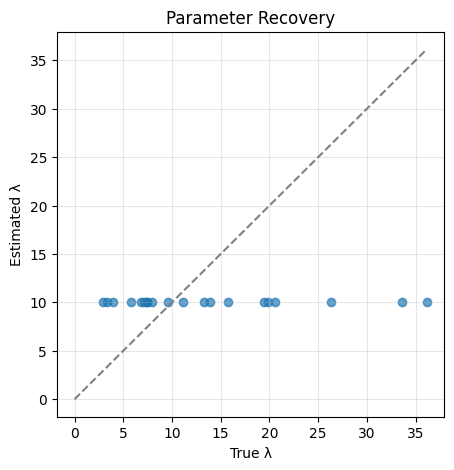

In [4]:
rl.init_priors((1, 0.1))

est_lambdas = rl.ev_estimate()
print(rl.true_lambdas)
print(est_lambdas)

plt.figure(figsize=(5,5))

plt.scatter(rl.true_lambdas, est_lambdas, alpha=0.7)

m = max(rl.true_lambdas.max(), est_lambdas.max())
plt.plot([0,m], [0,m], "--", color="gray")

plt.xlabel("True λ")
plt.ylabel("Estimated λ")
plt.title("Parameter Recovery")

plt.grid(alpha=0.3)
plt.show()

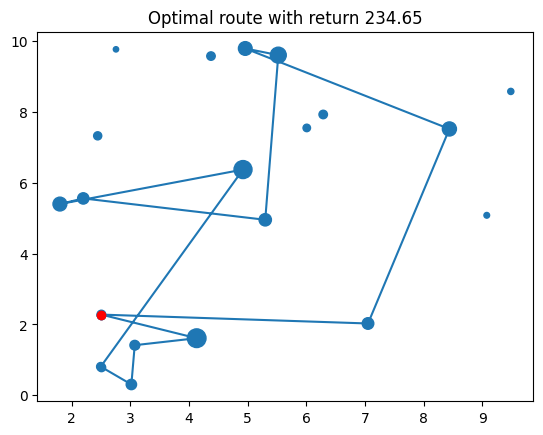

In [5]:
optimal_route, opt_ret = greedy_solver(rl.dist, rl.true_lambdas, start=rl.start, time_window=rl.time_window)
# print(optimal_route, opt_ret)
route_coords = points[optimal_route]
plt.scatter(rl.points[:, 0], rl.points[:, 1], s=true_lambdas*5)
plt.scatter(*route_coords[-1], color="red", zorder=3, label="End")
plt.title("Optimal route with return %.2f" % opt_ret)
plt.plot(route_coords[:, 0], route_coords[:, 1], marker='o')
plt.show()

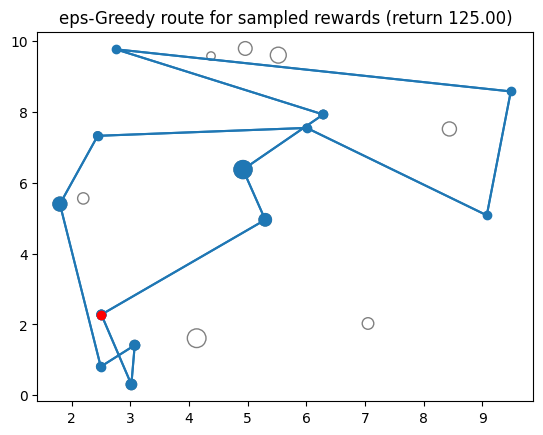

In [6]:
est_route_info = rl.thompson_sample(epsilon=0.05)
est_route = [node for node, _ in est_route_info]
ev_ret = sum(rew for _, rew in est_route_info)
est_route_coords = rl.points[est_route]
# plot all points (not in route: hollow, in route: filled)
plt.scatter(rl.points[:, 0], rl.points[:, 1], s=true_lambdas*5, facecolors="none", edgecolors="gray")
plt.scatter(est_route_coords[:,0], est_route_coords[:,1], s=true_lambdas[est_route]*5, color="tab:blue")
# plot line
plt.plot(est_route_coords[:, 0], est_route_coords[:, 1], color="tab:blue")
# mark starting node
plt.scatter(*est_route_coords[-1], color="red", zorder=3, label="End")

plt.title("eps-Greedy route for sampled rewards (return %.2f)" % ev_ret)
plt.plot(est_route_coords[:, 0], est_route_coords[:, 1], marker='o')
plt.show()

In [7]:
import ipywidgets as widgets
from IPython.display import display


routes = []
eps = 0.01
num_days = 10

for t in range(num_days):
    est_ev_route, ev_ret = rl.ev_route()
    routes.append((est_ev_route, ev_ret))
    routes_info = rl.thompson_sample(epsilon=eps)
    rl.thompson_update(routes_info)


def plot_route(i):

    est_route, ev_ret = routes[i]

    est_route_coords = rl.points[est_route]

    plt.figure(figsize=(6,6))

    plt.scatter(rl.points[:,0], rl.points[:,1],
                s=true_lambdas*5,
                facecolors="none",
                edgecolors="gray")

    plt.scatter(est_route_coords[:,0], est_route_coords[:,1],
                s=true_lambdas[est_route]*5,
                color="tab:blue")

    plt.scatter(*est_route_coords[-1], color="darkblue", zorder=3, label="End")
    
    plt.plot(est_route_coords[:,0], est_route_coords[:,1], "--")

    plt.title(f"Iteration {i} | return={ev_ret:.2f}")
    plt.show()

widgets.interact(plot_route, i=(0, len(routes)-1))

interactive(children=(IntSlider(value=4, description='i', max=9), Output()), _dom_classes=('widget-interact',)…

<function __main__.plot_route(i)>

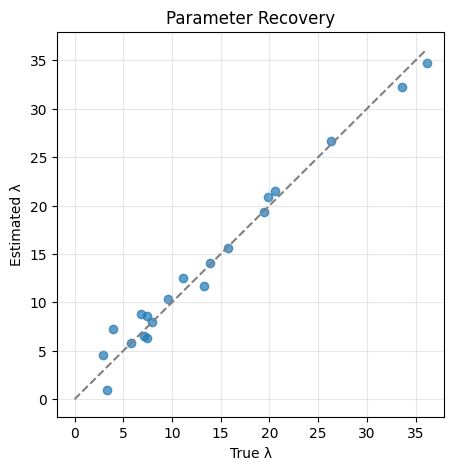

In [8]:
est_lambdas = rl.ev_estimate()

plt.figure(figsize=(5,5))

plt.scatter(rl.true_lambdas, est_lambdas, alpha=0.7)

m = max(rl.true_lambdas.max(), est_lambdas.max())
plt.plot([0,m], [0,m], "--", color="gray")

plt.xlabel("True λ")
plt.ylabel("Estimated λ")
plt.title("Parameter Recovery")

plt.grid(alpha=0.3)
plt.show()


In [9]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

routes = []
est_lambda_hist = []

eps = 0.01
num_days = 10

for t in range(num_days):

    est_ev_route, ev_ret = rl.ev_route()
    routes.append((est_ev_route, ev_ret))

    est_lambda_hist.append(rl.ev_estimate().copy())

    routes_info = rl.thompson_sample(epsilon=eps)
    rl.thompson_update(routes_info)


def plot_route(i):

    est_route, ev_ret = routes[i]
    ev_route_time = sum(rl.dist[u, v] for u, v in zip(est_route[:-1], est_route[1:]))
    est_lambdas = est_lambda_hist[i]

    est_route_coords = rl.points[est_route]

    fig, ax = plt.subplots(1,2, figsize=(12,5))

    # route plot
    ax[0].scatter(rl.points[:,0], rl.points[:,1],
                  s=true_lambdas*5,
                  facecolors="none",
                  edgecolors="gray")

    ax[0].scatter(est_route_coords[:,0], est_route_coords[:,1],
                  s=true_lambdas[est_route]*5,
                  color="tab:blue")

    ax[0].scatter(*est_route_coords[-1],
                  color="darkblue", zorder=3)

    ax[0].plot(est_route_coords[:,0], est_route_coords[:,1], "--")

    ax[0].set_title(f"Iteration {i}: return={ev_ret:.2f}, time={ev_route_time:.2f}")
    ax[0].grid(alpha=0.3)


    # true vs estimated parameter scatter plot
    ax[1].scatter(rl.true_lambdas, est_lambdas, alpha=0.7)

    m = max(rl.true_lambdas.max(), est_lambdas.max())
    ax[1].plot([0,m], [0,m], "--", color="gray")

    ax[1].set_xlabel("True lambda")
    ax[1].set_ylabel("Estimated lambda")
    ax[1].set_title("Parameter recovery")
    ax[1].grid(alpha=0.3)

    plt.show()


widgets.interact(plot_route, i=(0, len(routes)-1));

interactive(children=(IntSlider(value=4, description='i', max=9), Output()), _dom_classes=('widget-interact',)…